In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
import random
import numpy as np
import os
import pandas as pd
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from torch.cuda.amp import GradScaler, autocast  # Para Mixed Precision Training
from tqdm import tqdm # Barra de progresso
import copy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
def set_seed(seed):
    """
    Sets random seeds for reproducibility across different libraries and environments.
    """
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed) # Garante operações baseadas em hash consistentes

    torch.manual_seed(seed) # seed da CPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)       # Define seed na GPU atual
        torch.cuda.manual_seed_all(seed)   # Define seed para todas as GPUs

        # Garante comporamento deterministico para backend cuDNN (para operações convolucionais)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        try:
            os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
            torch.use_deterministic_algorithms(True)
        except RuntimeError as e:
            print(f"Warning: Could not set deterministic algorithms. Error: {e}")
            print("Some PyTorch operations might still be non-deterministic. Consider reviewing PyTorch version and operation types.")

set_seed(42)

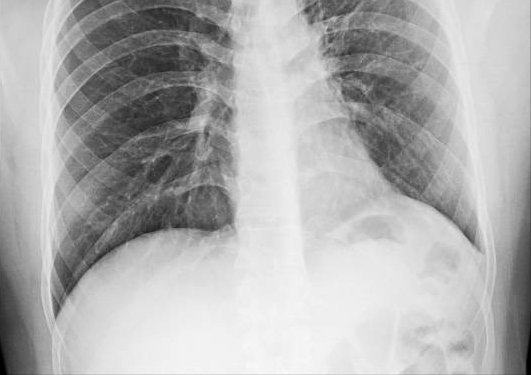

In [4]:
caminho_imagem = "D:/iniciacao_cientifica/untreated_images/images/Entry_ROI/img525.png"
imagem = Image.open(caminho_imagem)
display(imagem)

In [5]:
# Defnição do diretório das imagens e do CSV
image_entry_roi_dir = r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI" # Using raw string for Windows paths
csv_path = r"D:\iniciacao_cientifica\iniciacao-cientifica\data\Data_Entry_Undergrad_Final.csv"
# Lendo os arquivos CSV
all_xray_df = pd.read_csv(csv_path)

# Mapeando caminhos
all_image_paths_map = {}
# Utilização do glob para encontrar todas as imagens
for full_path in glob(os.path.join(image_entry_roi_dir, '*.png')):
    # Chave == filename para ser o mesmo que os Image Labels
    filename = os.path.basename(full_path)
    all_image_paths_map[filename] = full_path

print('Image files found in D:/.../Entry_ROI:', len(all_image_paths_map))
print('Total entries in CSV:', all_xray_df.shape[0])

all_xray_df['path'] = all_xray_df['Image Label'].map(all_image_paths_map.get)

# Depurar imagens não-encontradas
unmapped_images_count = all_xray_df['path'].isnull().sum()
if unmapped_images_count > 0:
    print(f"\nWarning: {unmapped_images_count} images in the CSV could not be mapped to a file path.")
    print(f"Removing {unmapped_images_count} unmapped entries...")
    all_xray_df.dropna(subset=['path'], inplace=True)
    print(f"Remaining rows: {len(all_xray_df)}")
else:
    print("\nAll CSV entries successfully mapped to image file paths.")

# Análise de dados ao nivel do paciente
print("\n--- Patient Data Analysis ---")
if 'Patient ID' in all_xray_df.columns:
    num_unique_patients = all_xray_df['Patient ID'].nunique()
    print(f"Total unique patients found: {num_unique_patients}")
    
    print("\nImages per patient summary:")

    print(all_xray_df['Patient ID'].value_counts().describe())
else:
    print("Warning: 'Patient ID' column not found in the CSV. Cannot perform patient-level analysis.")

print("\nSample of the prepared DataFrame:")
print(all_xray_df[['Patient ID', 'Image Label', 'Finding Labels', 'path']].sample(3))

Image files found in D:/.../Entry_ROI: 1072
Total entries in CSV: 1072

All CSV entries successfully mapped to image file paths.

--- Patient Data Analysis ---
Total unique patients found: 587

Images per patient summary:
count    587.000000
mean       1.826235
std        2.487606
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       18.000000
Name: count, dtype: float64

Sample of the prepared DataFrame:
      Patient ID  Image Label Finding Labels  \
992          567   img993.png             TB   
746          511   img747.png             TB   
1066         587  img1067.png             TB   

                                                   path  
992   D:\iniciacao_cientifica\untreated_images\image...  
746   D:\iniciacao_cientifica\untreated_images\image...  
1066  D:\iniciacao_cientifica\untreated_images\image...  


In [6]:
image_entry_roi_dir = r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI"
csv_path = r"D:\iniciacao_cientifica\iniciacao-cientifica\data\Data_Entry_Undergrad_Final.csv"

all_xray_df = pd.read_csv(csv_path)

# Mapear caminhos para as imagens 
all_image_paths_map = {os.path.basename(p): p for p in glob(os.path.join(image_entry_roi_dir, '*.png'))}
all_xray_df['path'] = all_xray_df['Image Label'].map(all_image_paths_map.get)

# Limpar imagens nao-mapeadas
unmapped_count = all_xray_df['path'].isnull().sum()
if unmapped_count > 0:
    print(f"Warning: Dropping {unmapped_count} rows from the CSV that did not have a matching image file.")
    all_xray_df.dropna(subset=['path'], inplace=True)

all_xray_df.reset_index(drop=True, inplace=True)

# Criar a coluna binária 'is_tb' para identificar imagens com TB
mapping_dict = {'TB': 1, 'No Findings': 0}
all_xray_df['is_tb'] = all_xray_df['Finding Labels'].map(mapping_dict)

print("--- Data Loading and Preparation Summary ---")
print(f"Total entries in CSV: {pd.read_csv(csv_path).shape[0]}")
print(f"Image files found in directory: {len(all_image_paths_map)}")
print(f"Final number of usable images after mapping: {len(all_xray_df)}")
print(f"Total unique patients: {all_xray_df['Patient ID'].nunique()}")
print("-" * 40)


# Divisão de dados para treino, validação e teste

print("\n--- Starting Patient-Aware Data Splitting ---")
# Criar Dataframe com uma linha por paciente para gerar splits
# Label do paciente é '1' se tem este tem qualquer imagem 'TB'
patient_df = all_xray_df.groupby('Patient ID').agg(
    is_tb=('is_tb', 'max') # 'max' garante que se qualquer imagem do paciente é 1, o label do paciente também é 1
).reset_index()

print(f"Created a patient-level DataFrame with {len(patient_df)} unique patients.")
print("Patient-level label distribution before splitting:")
print(patient_df['is_tb'].value_counts())

# Split pacientes nos datasets de treino (80%) e validação (20% para validação e testes)
# Stratify usando label 'is_tb' para manter distribuição
train_patients, temp_patients = train_test_split(
    patient_df,
    test_size=0.2,
    random_state=42,
    stratify=patient_df['is_tb']
)

# Split nos pacientes de validação para seus respectivos datasets
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.5, # 50% dos 20% do dataset temporário == 10% do total
    random_state=42,
    stratify=temp_patients['is_tb']
)

# Criar lista de ID pacientes para cada dataset
train_patient_ids = train_patients['Patient ID'].tolist()
val_patient_ids = val_patients['Patient ID'].tolist()
test_patient_ids = test_patients['Patient ID'].tolist()

# Criar DataFrames finais filtrando o DataFrame original
train_df = all_xray_df[all_xray_df['Patient ID'].isin(train_patient_ids)].copy()
val_df = all_xray_df[all_xray_df['Patient ID'].isin(val_patient_ids)].copy()
test_df = all_xray_df[all_xray_df['Patient ID'].isin(test_patient_ids)].copy()


# Verificação e Resumo
print("\n--- Verification ---")
# Checkagem final para ver se não existe overlap (mistura) de pacientes nos datasets
train_ids_set = set(train_df['Patient ID'])
val_ids_set = set(val_df['Patient ID'])
test_ids_set = set(test_df['Patient ID'])

assert len(train_ids_set.intersection(val_ids_set)) == 0, "FATAL: Patient overlap found between train and validation sets!"
assert len(train_ids_set.intersection(test_ids_set)) == 0, "FATAL: Patient overlap found between train and test sets!"
assert len(val_ids_set.intersection(test_ids_set)) == 0, "FATAL: Patient overlap found between validation and test sets!"
print("Verification successful: No patient overlap between train, validation, and test sets.")

print("\n--- Data Split Summary ---")
print(f"Total Patients: {len(patient_df)}")
print(f"Training Patients: {len(train_patient_ids)} | Validation Patients: {len(val_patient_ids)} | Test Patients: {len(test_patient_ids)}")
print("-" * 40)
print(f"Total Images: {len(all_xray_df)}")
print(f"Training Images: {len(train_df)} | Validation Images: {len(val_df)} | Test Images: {len(test_df)}")

print("\nTraining Set Label Distribution (Images):")
print(train_df['is_tb'].value_counts())
print("\nValidation Set Label Distribution (Images):")
print(val_df['is_tb'].value_counts())
print("\nTest Set Label Distribution (Images):")
print(test_df['is_tb'].value_counts())

--- Data Loading and Preparation Summary ---
Total entries in CSV: 1072
Image files found in directory: 1072
Final number of usable images after mapping: 1072
Total unique patients: 587
----------------------------------------

--- Starting Patient-Aware Data Splitting ---
Created a patient-level DataFrame with 587 unique patients.
Patient-level label distribution before splitting:
is_tb
0    439
1    148
Name: count, dtype: int64

--- Verification ---
Verification successful: No patient overlap between train, validation, and test sets.

--- Data Split Summary ---
Total Patients: 587
Training Patients: 469 | Validation Patients: 59 | Test Patients: 59
----------------------------------------
Total Images: 1072
Training Images: 857 | Validation Images: 107 | Test Images: 108

Training Set Label Distribution (Images):
is_tb
1    506
0    351
Name: count, dtype: int64

Validation Set Label Distribution (Images):
is_tb
1    63
0    44
Name: count, dtype: int64

Test Set Label Distribution 

--- Balancing the Training Set ---
Original training set image counts:
is_tb
1    506
0    351
Name: count, dtype: int64

Minority class 'No TB (0)' count in training set: 351
Undersampling majority class 'TB (1)' to match this count.

--- Final Dataset Counts ---
Balanced Training Set Counts:
is_tb
1    351
0    351
Name: count, dtype: int64

Validation Set Counts (Unchanged):
is_tb
1    63
0    44
Name: count, dtype: int64

Test Set Counts (Unchanged):
is_tb
1    64
0    44
Name: count, dtype: int64


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_17640\3135708708.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=tb_values, ax=ax1, palette="viridis")


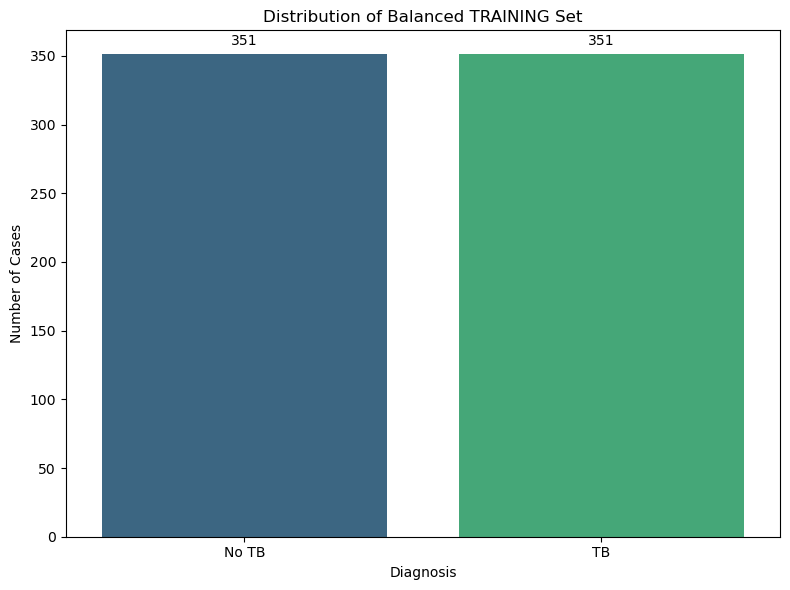


Sample of the new BALANCED Training DataFrame:


,Patient ID,Image Label,Finding Labels,path,is_tb
559,538,img869.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
477,510,img742.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
486,155,img155.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
427,238,img238.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
440,451,img496.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1


In [7]:
print("--- Balancing the Training Set ---")
print("Original training set image counts:")
print(train_df['is_tb'].value_counts())

# Separando o conjunto de treinamento em classes majoritarias e minoritarias
if (train_df['is_tb'] == 0).sum() > (train_df['is_tb'] == 1).sum():
    majority_df = train_df[train_df['is_tb'] == 0]
    minority_df = train_df[train_df['is_tb'] == 1]
    majority_label = 'No TB (0)'
    minority_label = 'TB (1)'
else:
    majority_df = train_df[train_df['is_tb'] == 1]
    minority_df = train_df[train_df['is_tb'] == 0]
    majority_label = 'TB (1)'
    minority_label = 'No TB (0)'

# Determinando o tamanho da classe minoritaria para se adequar a classe majoritaria (undersampling)
minority_count = len(minority_df)
print(f"\nMinority class '{minority_label}' count in training set: {minority_count}")
print(f"Undersampling majority class '{majority_label}' to match this count.")

# Reamostragem da classe majoritaria para se adequar a classe minoritaria (undersampling)
majority_resampled_df = majority_df.sample(n=minority_count, random_state=42)

# Combinando a classe minoritaria com a classe majoritaria (reamostra) -> dataset balanceado
train_df_balanced = pd.concat([minority_df, majority_resampled_df]).reset_index(drop=True)

# Ordem aleadória do DataFrame
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# DataFrames Finais
# Datasets de validação e teste não são alterados
print("\n--- Final Dataset Counts ---")
print("Balanced Training Set Counts:")
print(train_df_balanced['is_tb'].value_counts())
print("\nValidation Set Counts (Unchanged):")
print(val_df['is_tb'].value_counts())
print("\nTest Set Counts (Unchanged):")
print(test_df['is_tb'].value_counts())


# Gera gráfico
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
balanced_counts = train_df_balanced['is_tb'].value_counts()
tb_categories = ['No TB', 'TB']

tb_values = [balanced_counts.get(0, 0), balanced_counts.get(1, 0)]

sns.barplot(x=tb_categories, y=tb_values, ax=ax1, palette="viridis")
ax1.set_title('Distribution of Balanced TRAINING Set')
ax1.set_ylabel('Number of Cases')
ax1.set_xlabel('Diagnosis')

# Contagem exata por barra
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.tight_layout()
plt.show()

# Sample do DataFrame de treinamento final
print("\nSample of the new BALANCED Training DataFrame:")
display(train_df_balanced[['Patient ID', 'Image Label', 'Finding Labels', 'path', 'is_tb']].sample(5))

Visualizing class distributions for the final train, validation, and test sets:


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_17640\3071631530.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=train_values, ax=axes[0], palette=colors)
C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_17640\3071631530.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=val_values, ax=axes[1], palette=colors)
C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_17640\3071631530.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=test_values, ax=axes[2], palette=colors)


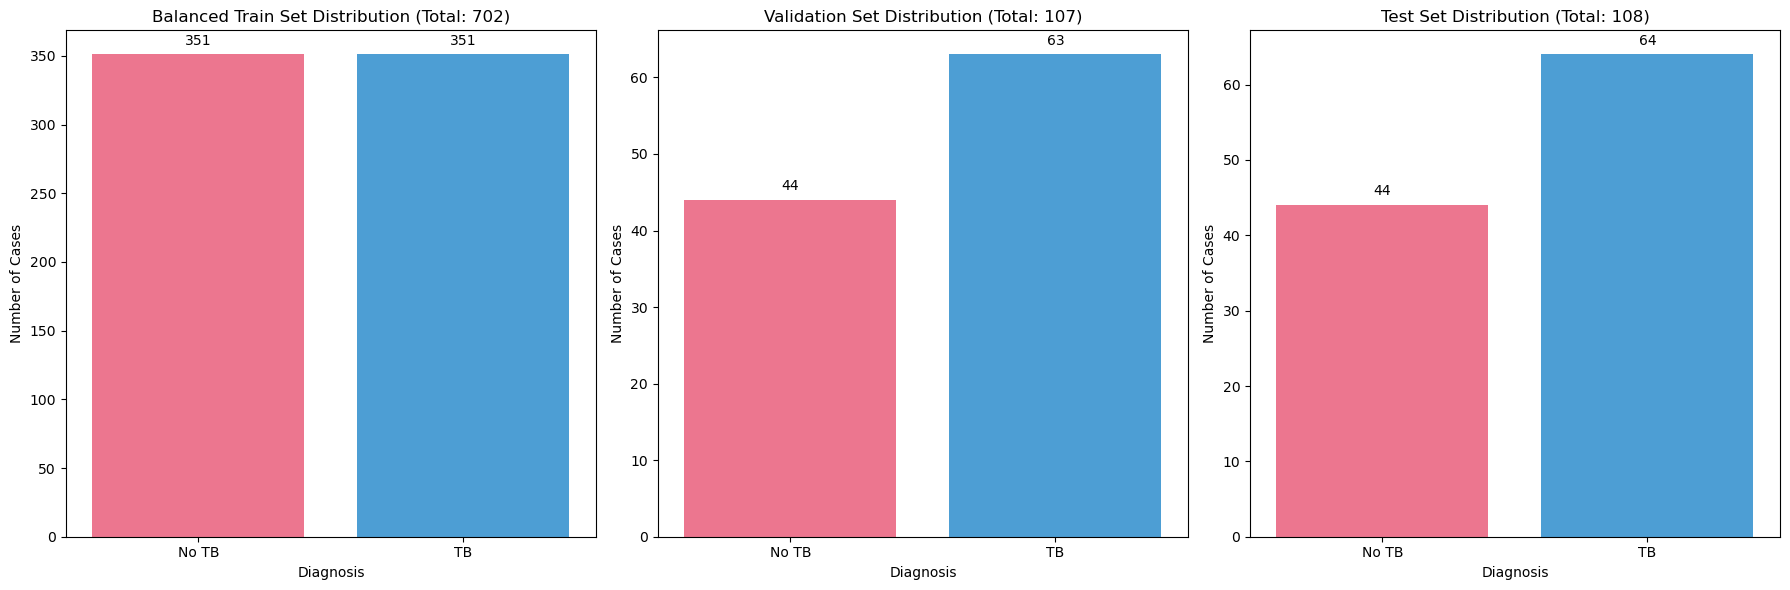

In [8]:
print("Visualizing class distributions for the final train, validation, and test sets:")
# Criar figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Ajustar tamanho da figura
tb_categories = ['No TB', 'TB']
colors = ['#FF6384', '#36A2EB']

# Usar o DataFrame 'train_df_balanced' para plotagem
train_counts = train_df_balanced['is_tb'].value_counts().sort_index()
train_values = [train_counts.get(0, 0), train_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=train_values, ax=axes[0], palette=colors)
axes[0].set_title(f'Balanced Train Set Distribution (Total: {len(train_df_balanced)})')
axes[0].set_ylabel('Number of Cases')
axes[0].set_xlabel('Diagnosis')
# Add exact counts on top of bars
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# --- UNCHANGED: Plot for Validation Set ---
val_counts = val_df['is_tb'].value_counts().sort_index()
val_values = [val_counts.get(0, 0), val_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=val_values, ax=axes[1], palette=colors)
axes[1].set_title(f'Validation Set Distribution (Total: {len(val_df)})')
axes[1].set_ylabel('Number of Cases')
axes[1].set_xlabel('Diagnosis')
# Contagem exata
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Plotagem dataset de teste
test_counts = test_df['is_tb'].value_counts().sort_index()
test_values = [test_counts.get(0, 0), test_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=test_values, ax=axes[2], palette=colors)
axes[2].set_title(f'Test Set Distribution (Total: {len(test_df)})')
axes[2].set_ylabel('Number of Cases')
axes[2].set_xlabel('Diagnosis')
# Contagem exata
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()  
plt.show() 

In [9]:
class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.dataframe = self._validate_image_paths()
    def _validate_image_paths(self):
        initial_count = len(self.dataframe)
        valid_paths_mask = self.dataframe['path'].apply(os.path.exists)
        invalid_paths_df = self.dataframe.loc[~valid_paths_mask]
        if not invalid_paths_df.empty:
            print(f"Warning: {len(invalid_paths_df)} images not found. Examples:")
            for img_path in invalid_paths_df['path'].head(5):
                print(f"  - {img_path}")
        validated_dataframe = self.dataframe[valid_paths_mask].reset_index(drop=True)
        if len(validated_dataframe) == 0:
            raise ValueError("No valid images found in the DataFrame after path validation.")
        if len(validated_dataframe) < initial_count:
            print(f"Dataset reduced from {initial_count} to {len(validated_dataframe)} valid images.")
        return validated_dataframe
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        try:
            image = Image.open(img_path).convert('RGB')
            label = self.dataframe.iloc[idx]['is_tb']
            label = torch.tensor(label, dtype=torch.float32)
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            raise RuntimeError(f"Error loading or processing image {img_path} at index {idx}: {e}") from e

def compute_dataset_stats(loader):
    total_pixels = torch.zeros(3)
    sum_pixel_values = torch.zeros(3)
    sum_squared_pixel_values = torch.zeros(3)
    print("Calculating dataset mean and std...")
    for i, (images, _) in enumerate(tqdm(loader, desc="Calculating Stats")):
        if images is None or images.numel() == 0 or images.dim() != 4:
            continue
        images_flat = images.view(images.size(0), images.size(1), -1)
        sum_pixel_values += images_flat.sum(dim=[0, 2])
        sum_squared_pixel_values += (images_flat ** 2).sum(dim=[0, 2])
        total_pixels += images_flat.size(0) * images_flat.size(2)
    if total_pixels.sum() == 0:
        raise ValueError("No valid image data processed to compute statistics.")
    mean = sum_pixel_values / total_pixels
    variance = (sum_squared_pixel_values / total_pixels) - (mean ** 2)
    std = torch.sqrt(torch.clamp(variance, min=0.0))
    return mean, std

# Checkagem do 'train_df_balanced' 
if 'train_df_balanced' not in locals():
    print("Error: 'train_df_balanced' not found. Please ensure the data splitting and balancing cells were run.")
    raise NameError("'train_df_balanced' not found.")

# Definir transformações mínimas
temp_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Criar dataset temporario e DataLoader temporário
try:
    print(f"\nAttempting to compute stats on {len(train_df_balanced)} images in train_df_balanced.")
    # MODIFIED: Use train_df_balanced
    temp_dataset = ChestXRayDataset(dataframe=train_df_balanced, transform=temp_transforms)
    
    temp_loader = DataLoader(
        temp_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0
    )
    
    # Calcular média e desvio padrão para dataset balanceado
    computed_mean, computed_std = compute_dataset_stats(temp_loader)
    
    # Print with formatting for clarity
    print("\n--- Computed Dataset Statistics (from balanced training set) ---")
    print(f"Mean (RGB channel-wise):     {computed_mean.tolist()}")
    print(f"Standard Dev (RGB channel-wise): {computed_std.tolist()}")
    print("------------------------------------------------------------------")
    
    # Armazenar variaveis
    global_dataset_mean = computed_mean
    global_dataset_std = computed_std
except Exception as e:
    print(f"An error occurred during dataset stats computation: {e}")


Attempting to compute stats on 702 images in train_df_balanced.
Calculating dataset mean and std...


Calculating Stats: 100%|██████████| 22/22 [01:50<00:00,  5.02s/it]



--- Computed Dataset Statistics (from balanced training set) ---
Mean (RGB channel-wise):     [0.5887839198112488, 0.5887839198112488, 0.5887839198112488]
Standard Dev (RGB channel-wise): [0.25975272059440613, 0.25975272059440613, 0.25975272059440613]
------------------------------------------------------------------


In [10]:
print(f"Using computed mean for normalization: {global_dataset_mean.tolist()}")
print(f"Using computed std for normalization: {global_dataset_std.tolist()}")

# 1. Transforms de treinamento (com Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images to 224x224 pixels
    transforms.RandomHorizontalFlip(),        # Randomly flip images horizontally
    transforms.RandomRotation(10),            # Randomly rotate images by +/- 10 degrees
    transforms.ColorJitter(                   # Randomly change brightness, contrast, saturation, hue
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.1
    ),
    transforms.ToTensor(),                    # Convert PIL Image to PyTorch Tensor (scales to [0,1])
    transforms.Normalize(                     # Normalize pixel values
        mean=global_dataset_mean,
        std=global_dataset_std
    )
])

# 2. Transforms de validação e teste (sem Data Augmentation) 
# Devem ser deterministicos para garantir avaliação consistente
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images to 224x224 pixels
    transforms.ToTensor(),                    # Convert PIL Image to PyTorch Tensor (scales to [0,1])
    transforms.Normalize(                     # Normalize pixel values
        mean=global_dataset_mean,
        std=global_dataset_std
    )
])

print("\nFinal image transformation pipelines defined:")
print("  - train_transforms (includes data augmentation)")
print("  - val_test_transforms (for validation and test sets)")

Using computed mean for normalization: [0.5887839198112488, 0.5887839198112488, 0.5887839198112488]
Using computed std for normalization: [0.25975272059440613, 0.25975272059440613, 0.25975272059440613]

Final image transformation pipelines defined:
  - train_transforms (includes data augmentation)
  - val_test_transforms (for validation and test sets)


In [11]:
# 1. Instanciar Datasets 
print("Instantiating datasets...")

train_dataset = ChestXRayDataset(dataframe=train_df_balanced, transform=train_transforms)
val_dataset = ChestXRayDataset(dataframe=val_df, transform=val_test_transforms)
test_dataset = ChestXRayDataset(dataframe=test_df, transform=val_test_transforms)

# Printar tamanhos finais dos datasets
print(f"Train Dataset size: {len(train_dataset)} images (from balanced set)")
print(f"Validation Dataset size: {len(val_dataset)} images (from original distribution)")
print(f"Test Dataset size: {len(test_dataset)} images (from original distribution)")

# 2. Criar DataLoaders
# Ajustanr tamanhos de batch
BATCH_SIZE = 32
NUM_WORKERS = 0 # 0 -> compatibilidade com Windows 10
print("\nCreating DataLoaders...")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # Aleatorizar os dados para melhor generalização
    num_workers=NUM_WORKERS,
    pin_memory=True 
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # Não aleatorizar para avalição
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # Não aleatorizar para avalição
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"DataLoaders created with batch size: {BATCH_SIZE}")
print(f"Number of batches in training: {len(train_loader)}")
print(f"Number of batches in validation: {len(val_loader)}")
print(f"Number of batches in testing: {len(test_loader)}")

try:
    sample_images, sample_labels = next(iter(train_loader))
    print(f"\nSample batch from training DataLoader - Images shape: {sample_images.shape}, Labels shape: {sample_labels.shape}")
except Exception as e:
    print(f"Could not retrieve sample batch: {e}")

Instantiating datasets...
Train Dataset size: 702 images (from balanced set)
Validation Dataset size: 107 images (from original distribution)
Test Dataset size: 108 images (from original distribution)

Creating DataLoaders...
DataLoaders created with batch size: 32
Number of batches in training: 22
Number of batches in validation: 4
Number of batches in testing: 4

Sample batch from training DataLoader - Images shape: torch.Size([32, 3, 224, 224]), Labels shape: torch.Size([32])


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def define_model(num_classes=1, freeze_pretrained=True):
    """
    Defines and customizes a pre-trained ResNet50 model for binary classification.

    Args:
        num_classes (int): The number of output classes. For binary classification, typically 1.
        freeze_pretrained (bool): If True, freezes the parameters of the pre-trained layers.
                                  Only the new classification head will be trained.
    Returns:
        torch.nn.Module: The configured ResNet50 model.
    """
    print("Loading pre-trained ResNet50 model...")
    # Carregar modelo ResNet50 com melhores pesos disponiveis
    model = resnet50(weights=ResNet50_Weights.DEFAULT)

    if freeze_pretrained:
        print("Freezing pre-trained layers...")
        for param in model.parameters():
            param.requires_grad = False

    # Armazenar numero de features na fc
    num_ftrs = model.fc.in_features

    # Trocar fc layer original por um novo para classificacao binaria
    # Classificacao Binaria -> output 1 (uma classe x outra)
    # BCEWithLogitsLoss -> adequado para ativação sigmoide
    model.fc = nn.Linear(num_ftrs, num_classes)
    print(f"Replaced final fully connected layer for {num_classes} output class(es).")

    # Mover modelo para o CUDA
    model = model.to(device)
    print(f"Model moved to {device}.")

    return model

# Instanciar modelo
model = define_model(num_classes=1, freeze_pretrained=True)

# Printar modelo
print("\nModel Architecture (last few layers relevant to changes):")
print(model.fc)
print(model.avgpool) 

# Example: Check if layers are frozen (should be False for fc, True for others if frozen)
# for name, param in model.named_parameters():
#     if "fc" not in name: # Check for non-fc layers
#         assert not param.requires_grad, f"Layer {name} is not frozen!"
#     else: # For fc layers
#         assert param.requires_grad, f"Layer {name} is unexpectedly frozen!"
# print("\nParameter freezing check passed (for fc vs other layers).")


Using device: cuda
Loading pre-trained ResNet50 model...
Freezing pre-trained layers...
Replaced final fully connected layer for 1 output class(es).
Model moved to cuda.

Model Architecture (last few layers relevant to changes):
Linear(in_features=2048, out_features=1, bias=True)
AdaptiveAvgPool2d(output_size=(1, 1))


In [13]:
print("Defining Loss Function and Optimizer...")

# 1. Definir Loss Function
criterion = nn.BCEWithLogitsLoss()
print(f"Loss Function: {criterion.__class__.__name__}")

# 2. Definir Otimizador
print("Setting up optimizer...")

optimizer = optim.Adam(model.fc.parameters(), lr=0.001) 
print(f"Optimizer: {optimizer.__class__.__name__} with Learning Rate: {optimizer.param_groups[0]['lr']}")
print("Note: Optimizer will only update parameters of the final 'fc' layer.")

from torch.optim import lr_scheduler
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1) # Reduzir LR por 10x a cada 7 epocas
print(f"Learning Rate Scheduler: {scheduler.__class__.__name__}")

print("\nLoss function, optimizer, and scheduler are configured.")

Defining Loss Function and Optimizer...
Loss Function: BCEWithLogitsLoss
Setting up optimizer...
Optimizer: Adam with Learning Rate: 0.001
Note: Optimizer will only update parameters of the final 'fc' layer.
Learning Rate Scheduler: StepLR

Loss function, optimizer, and scheduler are configured.


In [14]:
# Definir numero de epocas
NUM_EPOCHS = 20 

def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs, device):
    """
    Trains and validates the PyTorch model.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_accuracy = 0.0
    
    scaler = GradScaler() if device.type == 'cuda' else None
    if scaler:
        print("Mixed precision training enabled (using GradScaler).")
    else:
        print("Training on CPU. Mixed precision not enabled.")

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []
    }

    print("\nStarting training...\n")
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            all_preds, all_labels = [], []

            for inputs, labels in tqdm(dataloader, desc=f"{phase} Phase E{epoch+1}"):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    
                    with torch.cuda.amp.autocast(enabled=(scaler is not None)):
                        outputs = model(inputs)
                        if labels.dim() == 1:
                            labels = labels.unsqueeze(1)
                        loss = criterion(outputs, labels)

                    # Backward + optimize somente em fase de treinamento
                    if phase == 'train':
                        if scaler:
                            scaler.scale(loss).backward()
                            scaler.step(optimizer)
                            scaler.update()
                        else: # backpropagation padrão para CPU
                            loss.backward()
                            optimizer.step()
                
                # Metricas
                preds_proba = torch.sigmoid(outputs)
                binary_preds = (preds_proba > 0.5).float()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(binary_preds == labels.data)
                
                all_preds.extend(binary_preds.view(-1).cpu().numpy())
                all_labels.extend(labels.view(-1).cpu().numpy())

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                if scheduler:
                    scheduler.step()
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            else: # Validacao
                val_accuracy = accuracy_score(all_labels, all_preds)
                val_precision = precision_score(all_labels, all_preds, zero_division=0)
                val_recall = recall_score(all_labels, all_preds, zero_division=0)
                val_f1 = f1_score(all_labels, all_preds, zero_division=0)
                
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(val_accuracy)
                history['val_precision'].append(val_precision)
                history['val_recall'].append(val_recall)
                history['val_f1'].append(val_f1)
                
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} (sklearn: {val_accuracy:.4f})')
                print(f'   Precision: {val_precision:.4f} Recall: {val_recall:.4f} F1-Score: {val_f1:.4f}')

                if val_accuracy > best_val_accuracy:
                    best_val_accuracy = val_accuracy
                    best_model_wts = copy.deepcopy(model.state_dict())
                    print(f'   -> New best validation accuracy: {best_val_accuracy:.4f}. Model weights saved.')
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Validation Accuracy: {best_val_accuracy:.4f}')
    
    model.load_state_dict(best_model_wts)
    return model, history

# Executar treinamento
final_trained_model, training_history_data = train_model(
    model, criterion, optimizer, scheduler,
    train_loader, val_loader, NUM_EPOCHS, device
)
print("\n--- Training Process Completed ---")
print("The model returned is the one with the best performance on the validation set.")
print("Training history data is stored in 'training_history_data' variable.")

# Salvar melhor modelo
SAVE_MODEL_DIR = r"D:\iniciacao_cientifica\iniciacao-cientifica\saved_models"
MODEL_FILENAME = "best_resnet50_tb_detector.pth"
FULL_SAVE_PATH = os.path.join(SAVE_MODEL_DIR, MODEL_FILENAME)

os.makedirs(SAVE_MODEL_DIR, exist_ok=True)
torch.save(final_trained_model.state_dict(), FULL_SAVE_PATH)
print(f"\nBest model state_dict saved to: {FULL_SAVE_PATH}")

C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_17640\3762499574.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if device.type == 'cuda' else None


Mixed precision training enabled (using GradScaler).

Starting training...

Epoch 1/20
--------------------


train Phase E1:   0%|          | 0/22 [00:00<?, ?it/s]C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_17640\3762499574.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
train Phase E1: 100%|██████████| 22/22 [01:40<00:00,  4.58s/it]


train Loss: 0.6200 Acc: 0.7336


val Phase E1: 100%|██████████| 4/4 [00:15<00:00,  3.81s/it]


...

val Loss: 0.2274 Acc: 0.9533 (sklearn: 0.9533)
   Precision: 0.9833 Recall: 0.9365 F1-Score: 0.9593

Epoch 20/20
--------------------


train Phase E20:   0%|          | 0/22 [00:00<?, ?it/s]C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_17640\3762499574.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
train Phase E20: 100%|██████████| 22/22 [01:37<00:00,  4.42s/it]


train Loss: 0.2425 Acc: 0.9373


val Phase E20: 100%|██████████| 4/4 [00:12<00:00,  3.08s/it]


val Loss: 0.2195 Acc: 0.9720 (sklearn: 0.9720)
   Precision: 0.9688 Recall: 0.9841 F1-Score: 0.9764

Training complete in 36m 29s
Best Validation Accuracy: 0.9720

--- Training Process Completed ---
The model returned is the one with the best performance on the validation set.
Training history data is stored in 'training_history_data' variable.

Best model state_dict saved to: D:\iniciacao_cientifica\iniciacao-cientifica\saved_models\best_resnet50_tb_detector.pth



Starting Test set evaluation...


Test Phase: 100%|██████████| 4/4 [00:15<00:00,  3.76s/it]


--- Test Set Results ---
Loss: 0.2254
Accuracy (Tensor): 0.9815
Accuracy (Sklearn): 0.9815
Precision: 0.9844
Recall: 0.9844
F1-Score: 0.9844
--------------------------


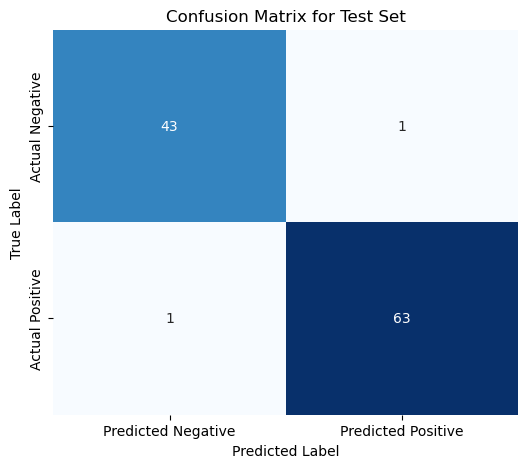


Test set evaluation complete. Results are stored in 'test_results' dictionary.


In [15]:
def evaluate_model(model, dataloader, criterion, device, phase="Test"):
    """
    Evaluates the model on the given DataLoader and computes various metrics.

    Args:
        model (torch.nn.Module): The trained model to evaluate.
        dataloader (DataLoader): DataLoader for the dataset to evaluate (e.g., test_loader).
        criterion (torch.nn.Module): The loss function.
        device (torch.device): The device (CPU or CUDA) to use for evaluation.
        phase (str): The name of the evaluation phase (e.g., "Test", "Validation").

    Returns:
        dict: A dictionary containing computed loss, accuracy, precision, recall, and F1-score.
    """
    model.eval()  # Definir modo de avaliação
    running_loss = 0.0
    running_corrects = 0
    all_preds = []
    all_labels = []

    print(f"\nStarting {phase} set evaluation...")
    with torch.no_grad():  
        for inputs, labels in tqdm(dataloader, desc=f"{phase} Phase"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            # para BCEWithLogitsLoss, labels devem ser (batch_size, 1)
            if labels.dim() == 1:
                labels = labels.unsqueeze(1)

            loss = criterion(outputs, labels)

            # Coverte logits para probabilidades e depois para predicoes binarias
            preds_proba = torch.sigmoid(outputs)
            binary_preds = (preds_proba > 0.5).float() # Threshold 0.5

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(binary_preds == labels.data)

            all_preds.extend(binary_preds.view(-1).cpu().numpy())
            all_labels.extend(labels.view(-1).cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc_tensor = running_corrects.double() / len(dataloader.dataset)

    # Calular metricas usando sklearn
    all_labels_np = np.array(all_labels)
    all_preds_np = np.array(all_preds)

    test_accuracy = accuracy_score(all_labels_np, all_preds_np)
    test_precision = precision_score(all_labels_np, all_preds_np, zero_division=0)
    test_recall = recall_score(all_labels_np, all_preds_np, zero_division=0)
    test_f1 = f1_score(all_labels_np, all_preds_np, zero_division=0)
    
    # Calcular Matriz de Confusão
    cm = confusion_matrix(all_labels_np, all_preds_np)

    print(f"\n--- {phase} Set Results ---")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Accuracy (Tensor): {epoch_acc_tensor:.4f}")
    print(f"Accuracy (Sklearn): {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"F1-Score: {test_f1:.4f}")
    print("--------------------------")

    # Plotar Matriz de Confusão
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {phase} Set')
    plt.show()

    return {
        'loss': epoch_loss,
        'accuracy_tensor': epoch_acc_tensor.item(),
        'accuracy_sklearn': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1_score': test_f1,
        'confusion_matrix': cm
    }

# Executar Validacao do dataset de teste
test_results = evaluate_model(final_trained_model, test_loader, criterion, device, phase="Test")

print("\nTest set evaluation complete. Results are stored in 'test_results' dictionary.")

Displaying 5 random images with predictions:
------------------------------------------------------------


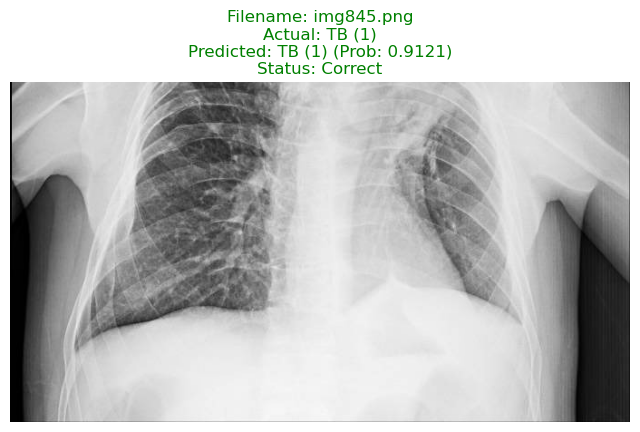

------------------------------------------------------------


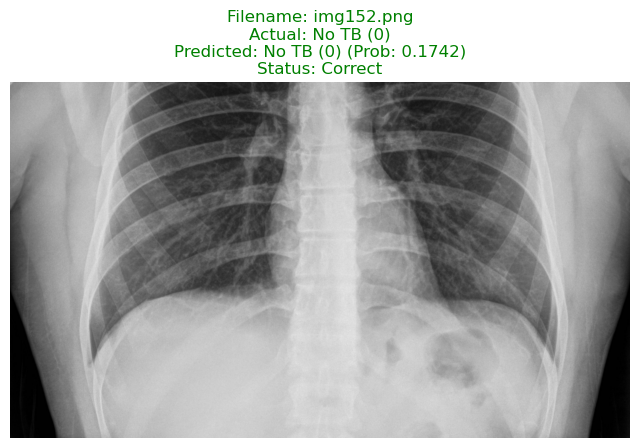

------------------------------------------------------------


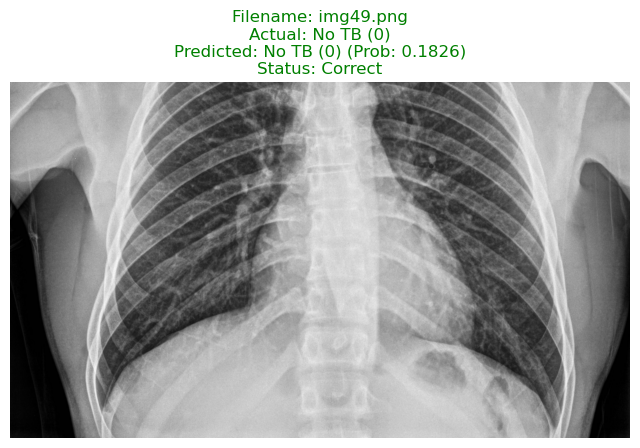

------------------------------------------------------------


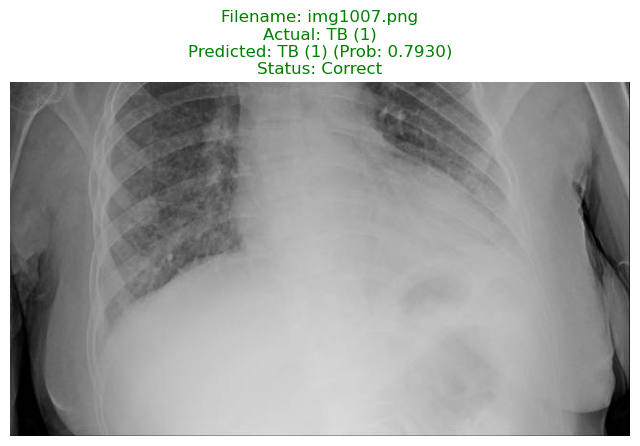

------------------------------------------------------------


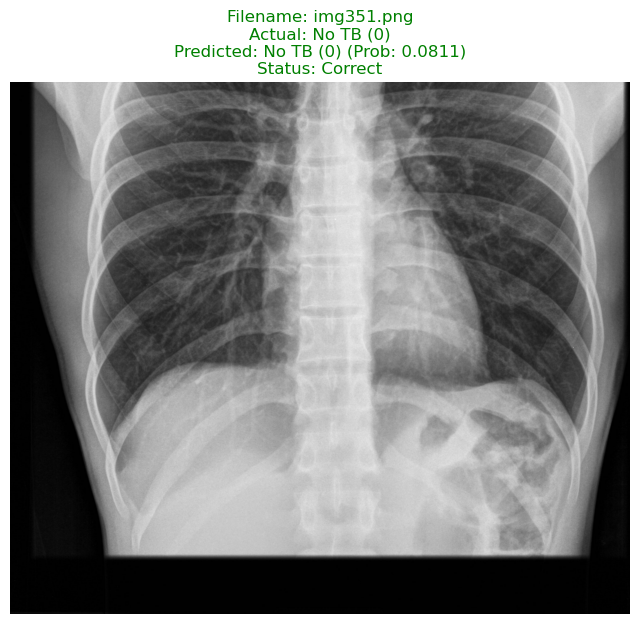

------------------------------------------------------------


In [16]:
# Modelo de avaliacao final 
final_trained_model.eval()

# Função auxiliar para converter logit para label
def get_label_name(label_value):
    return "TB" if label_value == 1 else "No TB"

def display_predictions(num_images=5):
    """
    Loads random images from the test set, makes predictions, and displays them
    alongside the actual label and model's prediction.
    """
    if len(test_df) == 0:
        print("Test DataFrame is empty. Cannot display predictions.")
        return

    print(f"Displaying {min(num_images, len(test_df))} random images with predictions:")
    print("-" * 60)

    # Converter test_df para uma lista de dict 
    test_samples = test_df.to_dict('records')

    # Selecionar indices aleatorios
    if len(test_samples) > num_images:
        selected_samples = random.sample(test_samples, num_images)
    else:
        selected_samples = test_samples

    for i, sample in enumerate(selected_samples):
        img_path = sample['path']
        true_label = sample['is_tb']
        filename = os.path.basename(img_path)

        try:
            # Carregar imagem original (display)
            original_image = Image.open(img_path).convert('RGB')

            # Aplicar transformacoes para entrada do modelo
            # Utilizar val_test_transforms original que utilizam ToTensor e Normalize
            input_tensor = val_test_transforms(original_image)
            input_batch = input_tensor.unsqueeze(0) # Adicionar dimensao de batch

            # Mover input para dispositivo
            input_batch = input_batch.to(device)

            # Predição
            with torch.no_grad():
                output_logits = final_trained_model(input_batch)
                prediction_proba = torch.sigmoid(output_logits).item() # Pegar probabilidade do logit
                predicted_label = 1 if prediction_proba > 0.5 else 0

            # Determina se acertou
            is_correct = (predicted_label == true_label)
            status_text = "Correct" if is_correct else "Incorrect"
            status_color = "green" if is_correct else "red"

            # Mostrar imagem
            plt.figure(figsize=(8, 7)) 
            plt.imshow(original_image)
            plt.axis('off')

            title_text = (
                f"Filename: {filename}\n"
                f"Actual: {get_label_name(true_label)} ({true_label})\n"
                f"Predicted: {get_label_name(predicted_label)} ({predicted_label}) (Prob: {prediction_proba:.4f})\n"
                f"Status: {status_text}"
            )
            plt.title(title_text, color=status_color)
            plt.show()

            print("-" * 60) # Separador para proxima imagem

        except Exception as e:
            print(f"Error processing image {filename} at path {img_path}: {e}")
            print("-" * 60)

display_predictions(num_images=5)